# Visor de Detecciones YOLO — VEO Panoramica

Visualiza las detecciones de jugadores y balon frame a frame con selector interactivo.

## Requisitos externos
- **Video panoramico VEO** (`data/videos/veo_panoramico_banyoles_1aParte.mp4`) — descargar con yt-dlp
- **Modelo YOLO jugadores** (`MODEL_PATH` en CONFIG) — entrenar con `train_yolo.py`
- **Homografias**: si no existen los .npy configurados, carga automaticamente `data/example_banyoles/H_camA.npy` y `H_camB.npy`
- **PKL prototipos**: si no existen, carga automaticamente `data/example_banyoles/prototypes_day.pkl` y `prototypes_night.pkl`


In [ ]:
# ════════════════════════════════════════════════════
#  CONFIGURACIÓN — edita aquí
# ════════════════════════════════════════════════════
VIDEO_PATH     = "data/videos/veo_panoramico_banyoles_1aParte.mp4"
PKL_DAY_PATH   = "prototypes_v3_day.pkl"
PKL_NIGHT_PATH = "prototypes_v3_night.pkl"
MODEL_PATH     = "runs/detect/modelo_players_v24_panoramic2/weights/best.pt"
H_A_PATH       = "data/calib_alpha1/calib_camA_alpha1_homography.npy"
H_B_PATH       = "data/calib_alpha1/calib_camB_alpha1_homography.npy"

START_FRAME = 18000
CONF        = 0.50
# -- Fallbacks a datos de ejemplo ----------------------------------
import os as _os
if not _os.path.exists(PKL_DAY_PATH):   PKL_DAY_PATH   = "data/example_banyoles/prototypes_day.pkl"
if not _os.path.exists(PKL_NIGHT_PATH): PKL_NIGHT_PATH = "data/example_banyoles/prototypes_night.pkl"
if not _os.path.exists(H_A_PATH):        H_A_PATH       = "data/example_banyoles/H_camA.npy"
if not _os.path.exists(H_B_PATH):        H_B_PATH       = "data/example_banyoles/H_camB.npy"


In [2]:
%matplotlib inline
import sys, cv2, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))

from pipeline_core import (
    preprocess_half, init_undistort_maps,
    get_grass_hue, get_torso_crop,
    get_hue_signature, get_hue_signature_masked,
    extract_sam_masks_batch, classify_player_v3, classify_player,
    pixel_to_field, esquinas_metros,
    _unify_seam, _global_nms,
    select_protos, draw_pitch_mpl,
    L_M, A_M, COLOR_MAP_HEX,
)
from ultralytics import YOLO

plt.rcParams.update({
    'figure.facecolor': '#0d0d18', 'axes.facecolor': '#0d0d18',
    'text.color': 'white', 'axes.labelcolor': '#aab',
    'xtick.color': '#556', 'ytick.color': '#556', 'axes.edgecolor': '#223',
})
print(' Imports OK')

✅ Imports OK


In [ ]:
# ─────────────────────────────────────────────────────
#  Cargar modelo, prototipos, homografías
# ─────────────────────────────────────────────────────
print(' Cargando YOLO...')
model = YOLO(MODEL_PATH)

with open(PKL_DAY_PATH,   'rb') as f: protos_day   = pickle.load(f)
with open(PKL_NIGHT_PATH, 'rb') as f: protos_night = pickle.load(f)
is_v3 = any('hue_sig' in p for p in protos_day.values())
print(f' PKL día: {list(protos_day.keys())} (v3={is_v3})')
print(f' PKL noche: {list(protos_night.keys())}')

H_a = np.load(H_A_PATH)
H_b = np.load(H_B_PATH)

cap_info = cv2.VideoCapture(VIDEO_PATH)
FPS     = cap_info.get(cv2.CAP_PROP_FPS) or 30.0
VID_W   = int(cap_info.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H   = int(cap_info.get(cv2.CAP_PROP_FRAME_HEIGHT))
N_TOTAL = int(cap_info.get(cv2.CAP_PROP_FRAME_COUNT))
cap_info.release()

HALF_H = VID_H // 2
init_undistort_maps(half_h=HALF_H, vid_w=VID_W)

corners_a = esquinas_metros(H_a, VID_W, HALF_H)
corners_b = esquinas_metros(H_b, VID_W, HALF_H)
LIMITE_X  = float(np.mean([corners_a[:, 0].max(), corners_b[:, 0].min()]))

print(f' {VID_W}×{VID_H} {FPS:.1f}fps {N_TOTAL} frames')
print(f' Costura: {LIMITE_X:.1f} m')

In [ ]:
# ─────────────────────────────────────────────────────
#  Helper: leer un frame y detectar en ambas mitades
# ─────────────────────────────────────────────────────
def read_frame(fidx):
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None


def detect_frame(frame, conf=CONF):
    """Devuelve (dets_unified, half_a_rgb, half_b_rgb)."""
    # Seleccionar PKL según iluminación del frame
    protos_cur = select_protos(frame, protos_day, protos_night)
    gh_a = get_grass_hue(frame[:HALF_H, :]) or 55.0
    gh_b = get_grass_hue(frame[HALF_H:, :]) or 55.0

    half_a = preprocess_half(frame[:HALF_H, :], 'left')
    half_b = preprocess_half(frame[HALF_H:, :], 'right')

    def _det_half(half_img, H, gh):
        results = model.predict(half_img, conf=conf, verbose=False)
        dets = []
        if not results or results[0].boxes is None:
            return dets
        boxes_np = results[0].boxes.xyxy.cpu().numpy()
        confs_np = results[0].boxes.conf.cpu().numpy()
        bboxes_l = [(int(b[0]),int(b[1]),int(b[2]),int(b[3])) for b in boxes_np]
        sam_masks = extract_sam_masks_batch(half_img, bboxes_l, None)
        for idx_b, (box, conf_v) in enumerate(zip(boxes_np, confs_np)):
            x1,y1,x2,y2 = float(box[0]),float(box[1]),float(box[2]),float(box[3])
            crop = half_img[max(0,int(y1)):int(y2), max(0,int(x1)):int(x2)]
            if crop.size == 0:
                continue
            mask  = sam_masks[idx_b] if idx_b < len(sam_masks) else None
            torso = get_torso_crop(crop)
            if is_v3:
                cls_name,score,margin,_ = classify_player_v3(crop, protos_cur, grass_hue=gh, mask=mask)
            else:
                cls_name, score = classify_player(torso, protos_cur, gh)
                margin = 0.0
            hue_s = (get_hue_signature_masked(crop, mask, gh)
                     if (is_v3 and mask is not None)
                     else (get_hue_signature(torso, gh) if is_v3 else None))
            try:
                xm, ym = pixel_to_field((x1+x2)/2, float(y2), H)
            except Exception:
                xm, ym = None, None
            dets.append({
                'bbox_px':    (int(x1),int(y1),int(x2),int(y2)),
                'conf':       float(conf_v),
                'cls':        cls_name,
                'cls_score':  float(score) if score is not None else 0.0,
                'cls_margin': float(margin),
                'pos_m':      (xm, ym) if xm is not None else None,
                'hue_sig':    hue_s.tolist() if hue_s is not None else None,
            })
        return dets

    dets_a = _det_half(half_a, H_a, gh_a)
    dets_b = _det_half(half_b, H_b, gh_b)

    unified = _unify_seam(
        [{**d, 'cam': 'A'} for d in dets_a],
        [{**d, 'cam': 'B'} for d in dets_b],
        cut_x=LIMITE_X)
    unified = _global_nms(unified)

    half_a_rgb = cv2.cvtColor(half_a, cv2.COLOR_BGR2RGB)
    half_b_rgb = cv2.cvtColor(half_b, cv2.COLOR_BGR2RGB)
    return unified, half_a_rgb, half_b_rgb


def _hex(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2],16)/255 for i in (0,2,4))

CLS_RGB = {k: _hex(v) for k, v in COLOR_MAP_HEX.items()}
CLS_RGB['unknown'] = _hex('#888888')

CLS_BGR = {
    'player_home': (60,  20, 220),
    'player_away': (220, 80,  20),
    'gk_home':     (220,  0, 220),
    'gk_away':     (200,180,   0),
    'referee':     ( 20,200, 200),
    'unknown':     (120,120, 120),
}

print(' Helpers definidos')

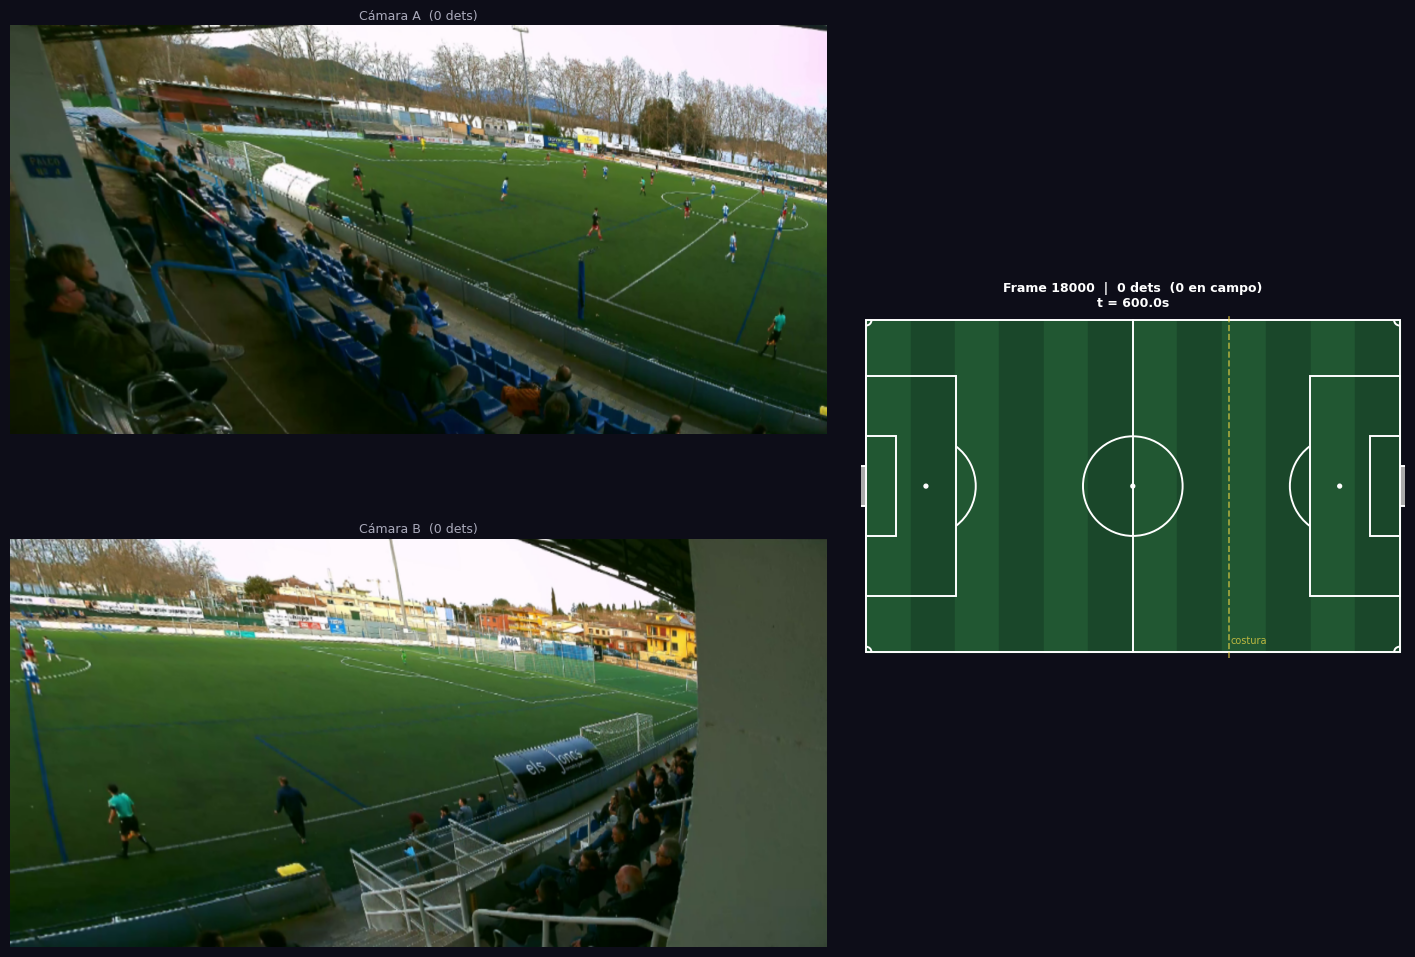

In [5]:
# ─────────────────────────────────────────────────────
#  Render de UN frame: cámaras + mapa de campo
# ─────────────────────────────────────────────────────
def draw_boxes(img_rgb, dets_cam, scale=1.0):
    """Dibuja bboxes sobre una copia de img_rgb."""
    out = img_rgb.copy()
    for d in dets_cam:
        x1,y1,x2,y2 = d['bbox_px']
        x1,y1,x2,y2 = int(x1*scale),int(y1*scale),int(x2*scale),int(y2*scale)
        col = CLS_BGR.get(d['cls'], (120,120,120))
        # Convertir RGB a BGR para cv2 (img ya es RGB, dibujamos en BGR order invertido)
        col_rgb = tuple(reversed(col))
        # dibujamos directamente en el array RGB
        cv2.rectangle(out, (x1,y1), (x2,y2),
                      color=tuple(int(c*255) for c in CLS_RGB.get(d['cls'],(0.5,0.5,0.5))),
                      thickness=2)
        label = f"{d['cls'].split('_')[-1][0].upper()}  {d['conf']:.2f}"
        cv2.putText(out, label, (x1, max(y1-4,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                    tuple(int(c*255) for c in CLS_RGB.get(d['cls'],(0.5,0.5,0.5))),
                    1, cv2.LINE_AA)
    return out


def render_frame(fidx, conf=CONF, show_labels=True, show_conf=True,
                 show_seam=True, figw=18):
    frame = read_frame(fidx)
    if frame is None:
        print(f' Frame {fidx} no disponible'); return

    dets, half_a_rgb, half_b_rgb = detect_frame(frame, conf=conf)
    dets_a = [d for d in dets if d.get('cam') == 'A']
    dets_b = [d for d in dets if d.get('cam') == 'B']

    img_a = draw_boxes(half_a_rgb, dets_a)
    img_b = draw_boxes(half_b_rgb, dets_b)

    fig = plt.figure(figsize=(figw, figw * 0.72), facecolor='#0d0d18')
    gs  = plt.GridSpec(2, 2, figure=fig,
                        height_ratios=[1, 1], width_ratios=[1.5, 1],
                        hspace=0.06, wspace=0.05)

    # ── Cámara A (top half)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.imshow(img_a)
    ax_a.set_title(f'Cámara A  ({len(dets_a)} dets)', color='#aab', fontsize=9, pad=4)
    ax_a.axis('off')

    # ── Cámara B (bottom half)
    ax_b = fig.add_subplot(gs[1, 0])
    ax_b.imshow(img_b)
    ax_b.set_title(f'Cámara B  ({len(dets_b)} dets)', color='#aab', fontsize=9, pad=4)
    ax_b.axis('off')

    # ── Mapa de campo (abarca las 2 filas)
    ax_m = fig.add_subplot(gs[:, 1])
    draw_pitch_mpl(ax_m, L_M, A_M)

    # Línea de costura
    if show_seam:
        ax_m.axvline(LIMITE_X, color='#fde047', lw=1.2, ls='--', alpha=0.6, zorder=4)
        ax_m.text(LIMITE_X + 0.4, A_M - 1.5, 'costura',
                  color='#fde047', fontsize=7, alpha=0.7, zorder=5)

    # Puntos de detección
    counts = {}
    for d in dets:
        if d['pos_m'] is None: continue
        xm, ym = d['pos_m']
        if not (0 <= xm <= L_M and 0 <= ym <= A_M): continue
        col = CLS_RGB.get(d['cls'], (0.5, 0.5, 0.5))
        ax_m.scatter(xm, ym, color=col, s=120, zorder=6,
                     edgecolors='white', linewidths=0.6)
        if show_labels:
            lbl = d['cls'].split('_')[-1][0].upper()
            txt = ax_m.text(xm, ym + 0.9, lbl, color=col,
                            fontsize=7, ha='center', zorder=7, fontweight='bold')
            txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground='black')])
        if show_conf:
            txt2 = ax_m.text(xm, ym - 1.3, f"{d['conf']:.2f}",
                             color='#ccc', fontsize=5.5, ha='center', zorder=7)
            txt2.set_path_effects([pe.withStroke(linewidth=1.2, foreground='black')])
        counts[d['cls']] = counts.get(d['cls'], 0) + 1

    # Leyenda con conteos
    legend_patches = [
        mpatches.Patch(color=CLS_RGB.get(cls, (0.5,0.5,0.5)),
                       label=f"{cls}  ({counts.get(cls,0)})")
        for cls in ['player_home','player_away','gk_home','gk_away','referee','unknown']
        if counts.get(cls, 0) > 0
    ]
    if legend_patches:
        ax_m.legend(handles=legend_patches, loc='lower right',
                    fontsize=7.5, facecolor='#0d0d18', labelcolor='white',
                    framealpha=0.85, edgecolor='#334')

    n_valid = sum(1 for d in dets if d['pos_m'] is not None)
    ax_m.set_title(
        f'Frame {fidx}  |  {len(dets)} dets  ({n_valid} en campo)\n'
        f't = {fidx/FPS:.1f}s',
        color='white', fontsize=9, fontweight='bold', pad=6)

    plt.tight_layout()
    display(fig)
    plt.close(fig)


# Vista rápida del frame de inicio
render_frame(START_FRAME)

In [6]:
# ─────────────────────────────────────────────────────
#  Visor interactivo — frame scrubber
# ─────────────────────────────────────────────────────
_out = widgets.Output()

_w_frame = widgets.IntSlider(
    value=START_FRAME, min=0, max=N_TOTAL-1, step=1,
    description='Frame:', continuous_update=False,
    style={'description_width': '60px'},
    layout=widgets.Layout(width='700px'))

_w_step = widgets.BoundedIntText(
    value=30, min=1, max=300, description='Paso:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='140px'))

_w_conf = widgets.FloatSlider(
    value=CONF, min=0.1, max=0.95, step=0.05,
    description='Conf:', continuous_update=False,
    style={'description_width': '50px'},
    layout=widgets.Layout(width='280px'))

_w_labels  = widgets.Checkbox(value=True,  description='Etiquetas', indent=False)
_w_confvis = widgets.Checkbox(value=True,  description='Conf. score', indent=False)
_w_seam    = widgets.Checkbox(value=True,  description='Costura', indent=False)

_w_prev  = widgets.Button(description='◀ Prev', layout=widgets.Layout(width='90px'))
_w_next  = widgets.Button(description='Next ▶', layout=widgets.Layout(width='90px'))
_w_go    = widgets.Button(description='▶ Renderizar', button_style='primary',
                           layout=widgets.Layout(width='130px'))
_w_time  = widgets.HTML(value='')

def _refresh(b=None):
    fidx = int(_w_frame.value)
    _w_time.value = f'<span style="color:#aab;font-size:12px">t = {fidx/FPS:.2f}s</span>'
    with _out:
        clear_output(wait=True)
        render_frame(fidx,
                     conf=float(_w_conf.value),
                     show_labels=bool(_w_labels.value),
                     show_conf=bool(_w_confvis.value),
                     show_seam=bool(_w_seam.value))

def _prev(b):
    _w_frame.value = max(0, _w_frame.value - int(_w_step.value))
    _refresh()

def _next(b):
    _w_frame.value = min(N_TOTAL-1, _w_frame.value + int(_w_step.value))
    _refresh()

_w_prev.on_click(_prev)
_w_next.on_click(_next)
_w_go.on_click(_refresh)

display(widgets.VBox([
    widgets.HBox([_w_frame, _w_time]),
    widgets.HBox([_w_prev, _w_next, _w_step, _w_conf, _w_go]),
    widgets.HBox([_w_labels, _w_confvis, _w_seam]),
    _out,
]))
_refresh()

In [7]:
# ─────────────────────────────────────────────────────
#  Mapa de densidad — acumula N frames y muestra heatmap
# ─────────────────────────────────────────────────────
SCAN_START  = START_FRAME
SCAN_FRAMES = 300   # ~10s a 30fps
SCAN_STEP   = 5     # procesar 1 de cada N frames para ir rápido

print(f'Escaneando {SCAN_FRAMES//SCAN_STEP} frames ({SCAN_FRAMES/FPS:.0f}s)...')

from scipy.ndimage import gaussian_filter

BINS_X, BINS_Y = int(L_M * 2), int(A_M * 2)
heat = {cls: np.zeros((BINS_Y, BINS_X), dtype=np.float32)
        for cls in ['player_home','player_away','gk_home','gk_away','referee','unknown']}
all_dets = []

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, SCAN_START)
for i in range(SCAN_FRAMES):
    ret, frame = cap.read()
    if not ret: break
    if i % SCAN_STEP != 0: continue
    dets, _, _ = detect_frame(frame)
    for d in dets:
        if d['pos_m'] is None: continue
        xm, ym = d['pos_m']
        if not (0 <= xm <= L_M and 0 <= ym <= A_M): continue
        all_dets.append(d)
        ix = int(np.clip(xm / L_M * (BINS_X-1), 0, BINS_X-1))
        iy = int(np.clip(ym / A_M * (BINS_Y-1), 0, BINS_Y-1))
        heat[d['cls']][iy, ix] += 1
    if (i // SCAN_STEP + 1) % 10 == 0:
        print(f'  {i+1}/{SCAN_FRAMES} frames...')
cap.release()
print(f' {len(all_dets)} detecciones acumuladas')

Escaneando 60 frames (10s)...
  46/300 frames...
  96/300 frames...
  146/300 frames...
  196/300 frames...
  246/300 frames...
  296/300 frames...
✅ 40 detecciones acumuladas


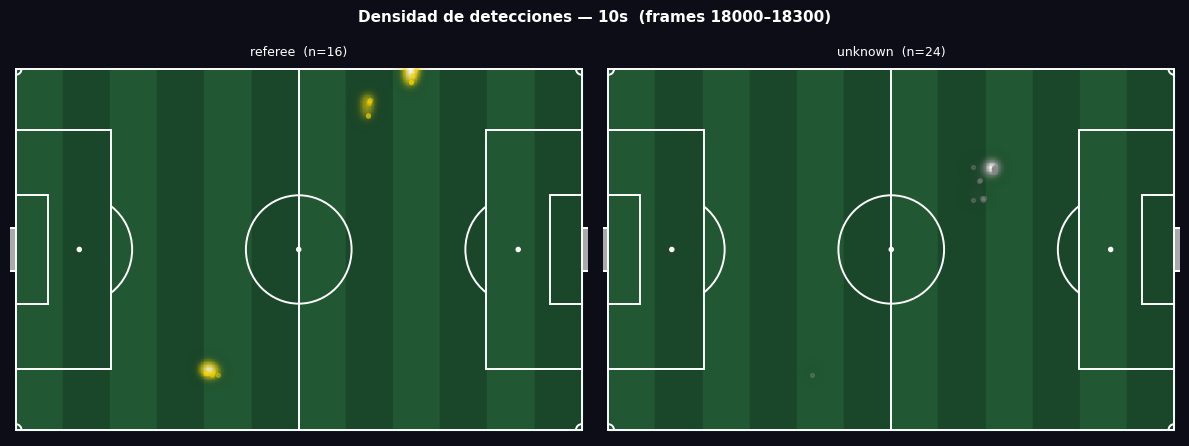

In [8]:
# ─────────────────────────────────────────────────────
#  Visualizar heatmaps por clase
# ─────────────────────────────────────────────────────
import matplotlib.colors as mcolors

classes_present = [cls for cls in heat if heat[cls].sum() > 0]
ncols = min(3, len(classes_present))
nrows = (len(classes_present) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 6, nrows * 4.5),
                          facecolor='#0d0d18')
if nrows * ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncols == 1:
    axes = axes[:, np.newaxis]

for idx, cls in enumerate(classes_present):
    r, c = divmod(idx, ncols)
    ax   = axes[r, c]
    draw_pitch_mpl(ax, L_M, A_M)

    h = gaussian_filter(heat[cls], sigma=2.5)
    if h.max() > 0:
        # Color base de la clase
        base  = CLS_RGB.get(cls, (0.5,0.5,0.5))
        cmap  = mcolors.LinearSegmentedColormap.from_list(
            cls, [(0,0,0,0), (*base, 0.15), (*base, 0.7), (1,1,1,0.95)])
        ax.imshow(h, origin='lower', extent=[0, L_M, 0, A_M],
                  cmap=cmap, aspect='auto', zorder=3)

    # Puntos individuales
    pts = [(d['pos_m'][0], d['pos_m'][1]) for d in all_dets
           if d['cls'] == cls and d['pos_m'] is not None]
    if pts:
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, s=8, color=CLS_RGB.get(cls,(0.5,0.5,0.5)),
                   alpha=0.35, zorder=4)

    ax.set_title(f'{cls}  (n={len(pts)})', color='white', fontsize=9, pad=5)

# Ocultar ejes sobrantes
for idx in range(len(classes_present), nrows*ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis('off')

fig.suptitle(f'Densidad de detecciones — {SCAN_FRAMES/FPS:.0f}s  '
             f'(frames {SCAN_START}–{SCAN_START+SCAN_FRAMES})',
             color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
display(fig); plt.close(fig)

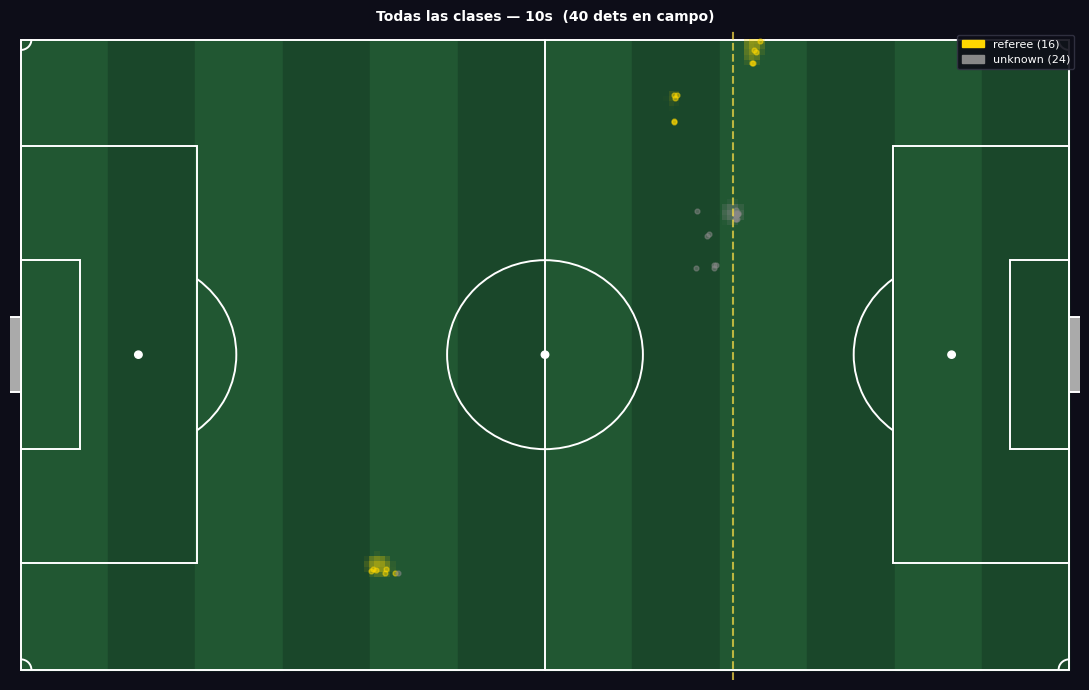

In [9]:
# ─────────────────────────────────────────────────────
#  Mapa combinado: home + away superpuestos
# ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7), facecolor='#0d0d18')
draw_pitch_mpl(ax, L_M, A_M)

for cls in classes_present:
    h = gaussian_filter(heat[cls], sigma=2.0)
    if h.max() == 0: continue
    base = CLS_RGB.get(cls, (0.5,0.5,0.5))
    cmap = mcolors.LinearSegmentedColormap.from_list(
        cls, [(0,0,0,0), (*base, 0.0), (*base, 0.55)])
    ax.imshow(h, origin='lower', extent=[0, L_M, 0, A_M],
              cmap=cmap, aspect='auto', zorder=3)

# Puntos con leyenda
legend_patches = []
for cls in classes_present:
    pts = [(d['pos_m'][0], d['pos_m'][1]) for d in all_dets
           if d['cls'] == cls and d['pos_m'] is not None]
    if pts:
        xs, ys = zip(*pts)
        col = CLS_RGB.get(cls,(0.5,0.5,0.5))
        ax.scatter(xs, ys, s=12, color=col, alpha=0.5, zorder=5)
        legend_patches.append(
            mpatches.Patch(color=col, label=f'{cls} ({len(pts)})'))

ax.axvline(LIMITE_X, color='#fde047', lw=1.5, ls='--', alpha=0.7, zorder=6)
ax.legend(handles=legend_patches, loc='upper right',
          fontsize=8, facecolor='#0d0d18', labelcolor='white',
          framealpha=0.9, edgecolor='#334')
ax.set_title(f'Todas las clases — {SCAN_FRAMES/FPS:.0f}s  '
             f'({len(all_dets)} dets en campo)',
             color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
display(fig); plt.close(fig)